In [24]:
import os
import sys
import torch
import cv2
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import json
from tqdm import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor
import umap as um

In [2]:
image_path = 'data/hypernerf/chickchicken/rgb/2x/000047.png'
mask_path = 'data/hypernerf/chickchicken/clip_features/000047_s.npy'
image = Image.open('data/hypernerf/chickchicken/rgb/2x/000047.png').convert("RGB")
input_size = 896
resized_image = image.resize( # non-uniform scaling to fit square
    (input_size, input_size), Image.Resampling.LANCZOS
)
def square_crop_image(image: Image.Image, xslide=0, yslide=0):
    side_length = min(image.width, image.height)
    wm, hm, rd = image.width // 2, image.height // 2, side_length // 2
    return image.crop((wm - rd - xslide, hm - rd - yslide, wm + rd - xslide, hm + rd - yslide))
cropped_image = square_crop_image(image, yslide=100).resize((input_size, input_size), Image.Resampling.LANCZOS)

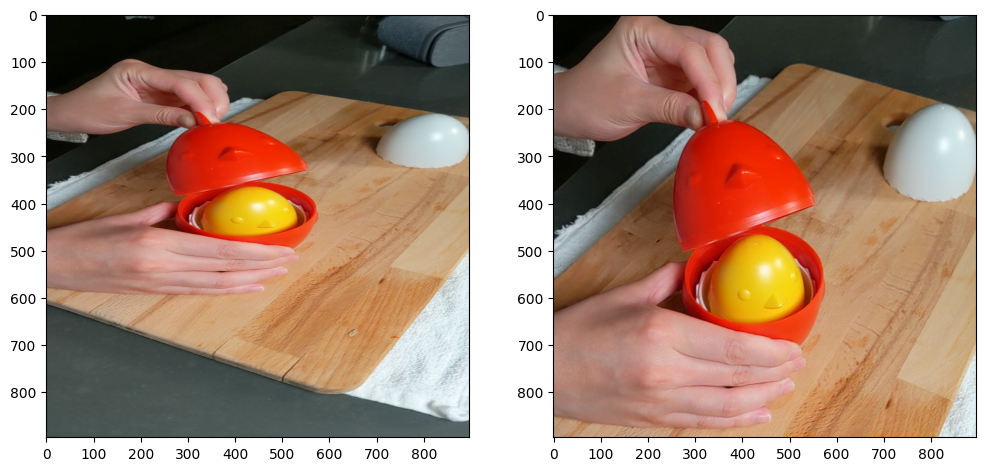

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 12))
axs[0].imshow(resized_image)
axs[1].imshow(cropped_image)
plt.show()

In [3]:
model_path = '/home/tumai/models/Qwen--Qwen2.5-VL-7B-Instruct'
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_path, dtype=torch.bfloat16, device_map="auto"
)
patch_size, spatial_merge = 14, 2 # model hyperparams
processor = Qwen2_5_VLProcessor.from_pretrained(model_path)
model.eval()
pass

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [4]:
def qwen_encode_image(image: Image.Image):
    image_inputs = processor.image_processor( #type:ignore
        images=[image], return_tensors="pt"
    )
    pixel_values = image_inputs["pixel_values"].to(model.device).to(torch.bfloat16)
    image_grid_thw = image_inputs["image_grid_thw"].to(model.device)
    with torch.no_grad():
        return model.visual(pixel_values, image_grid_thw)

def patches_to_2d(patch_features: torch.Tensor, src_image: Image.Image):
    effective_patch_size = patch_size * spatial_merge
    patches_width, patches_height = src_image.width // effective_patch_size, src_image.height // effective_patch_size
    return patch_features.reshape(patches_height, patches_width, -1)

In [5]:
# Extract vision features
patch_features = qwen_encode_image(image)
# patch_features shape: [num_patches, 3584]
patch_features_2d = patches_to_2d(patch_features, image)
# patch_features_2d shape [image.height // effective_patch_size, image.width // effective_patch_size, 3584]

In [55]:
pca = PCA(n_components=3)
patch_features_pca = pca.fit_transform(patch_features.cpu().to(torch.float16).numpy())
scaler = MinMaxScaler(); patch_features_pca = scaler.fit_transform(patch_features_pca)
patch_features_pca_2d = patches_to_2d(patch_features_pca, image)

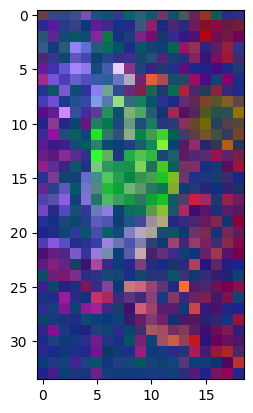

In [56]:
plt.imshow(patch_features_pca_2d)
plt.show()

In [33]:
umap = um.UMAP(n_components=3)
patch_features_umap = umap.fit_transform(patch_features.cpu().detach().to(torch.float32).numpy())
umap_scaler = MinMaxScaler((1e-4, 1-1e-4)) #type:ignore
patch_features_umap = umap_scaler.fit_transform(patch_features_umap) #type:ignore
patch_features_umap_2d = patches_to_2d(patch_features_umap, image)

/home/tumai/miniconda3/envs/rn4ds/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


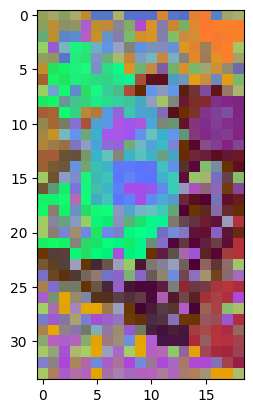

In [52]:
plt.imshow(patch_features_umap_2d)
plt.show()

In [20]:
def patch_cds(src_image: Image.Image):
    effective_patch_size = patch_size * spatial_merge
    patches_width, patches_height = src_image.width // effective_patch_size, src_image.height // effective_patch_size
    patch_coords_list = []
    for i in range(patches_height):
        for j in range(patches_width):
            y1 = i * effective_patch_size
            y2 = min((i + 1) * effective_patch_size, src_image.height)
            x1 = j * effective_patch_size
            x2 = min((j + 1) * effective_patch_size, src_image.width)
            patch_coords_list.append((y1, y2, x1, x2))
    cds: torch.Tensor = torch.as_tensor(patch_coords_list)
    cds: torch.Tensor = cds.reshape(patches_height, patches_width, 2, 2)
    return cds
patch_coords = patch_cds(image)

In [35]:
masks = np.load(mask_path)[1]
# masks = cv2.resize(
#     masks,
#     (input_size, input_size),
#     interpolation=cv2.INTER_NEAREST,
# )

In [ ]:
for mask_id in np.unique(masks):
    plt.imshow(masks == mask_id)
    plt.title(str(mask_id))
    plt.show()

In [37]:
mask_names = {
    -1 : "board",
    35 : "table",
    36 : "right hand",
    37 : "left hand",
    38 : "outer chicken egg",
    72 : "inner chicken egg",
} 

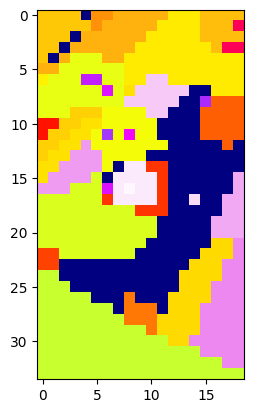

In [38]:
patch_centers = patch_coords.to(torch.float16).mean(dim=-1).to(torch.long) 
patch_masks = masks[patch_centers[..., 0], patch_centers[..., 1]]
plt.imshow(patch_masks, cmap='gist_ncar')
plt.show()

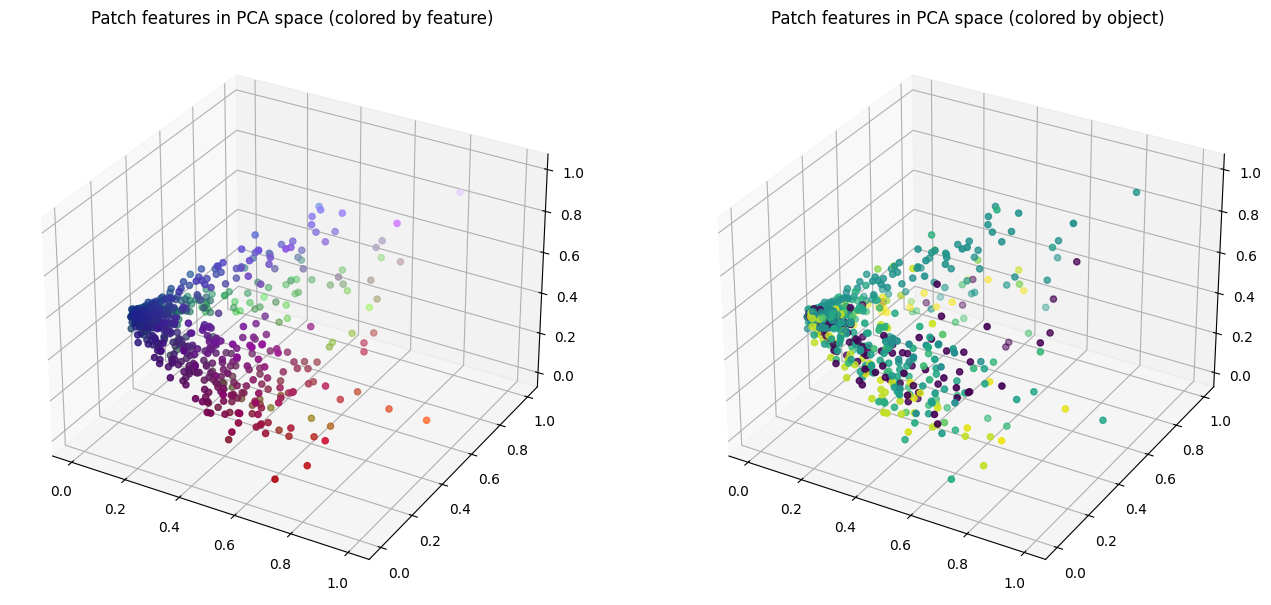

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(16, 16), subplot_kw=dict(projection='3d'))
axs[0].scatter(*patch_features_pca.T, c=patch_features_pca)
axs[0].set_title("Patch features in PCA space (colored by feature)")
axs[1].scatter(*patch_features_pca.T, c=patch_masks.flatten())
axs[1].set_title("Patch features in PCA space (colored by object)")
plt.show()

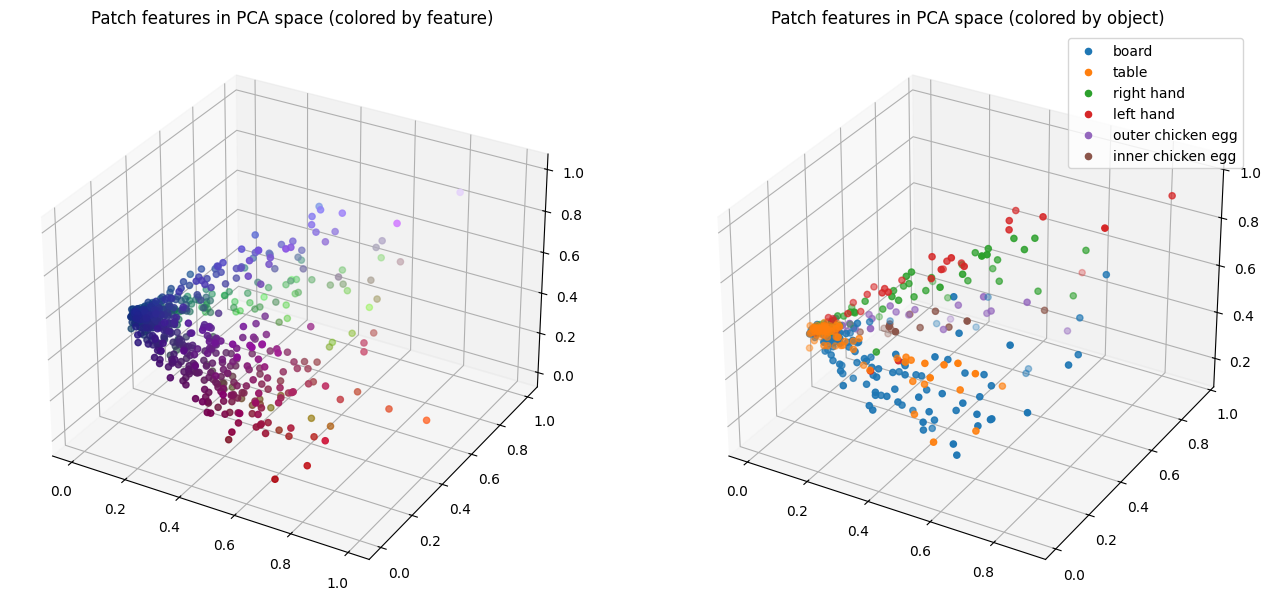

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(16, 16), subplot_kw=dict(projection='3d'))
axs[0].scatter(*patch_features_pca.T, c=patch_features_pca)
axs[0].set_title("Patch features in PCA space (colored by feature)")
for mask_id in np.unique(patch_masks):
    if mask_id in mask_names.keys():
        axs[1].scatter(*patch_features_pca[patch_masks.flatten() == mask_id].T, label=mask_names[mask_id])
axs[1].set_title("Patch features in PCA space (colored by object)")
axs[1].legend()
plt.show()

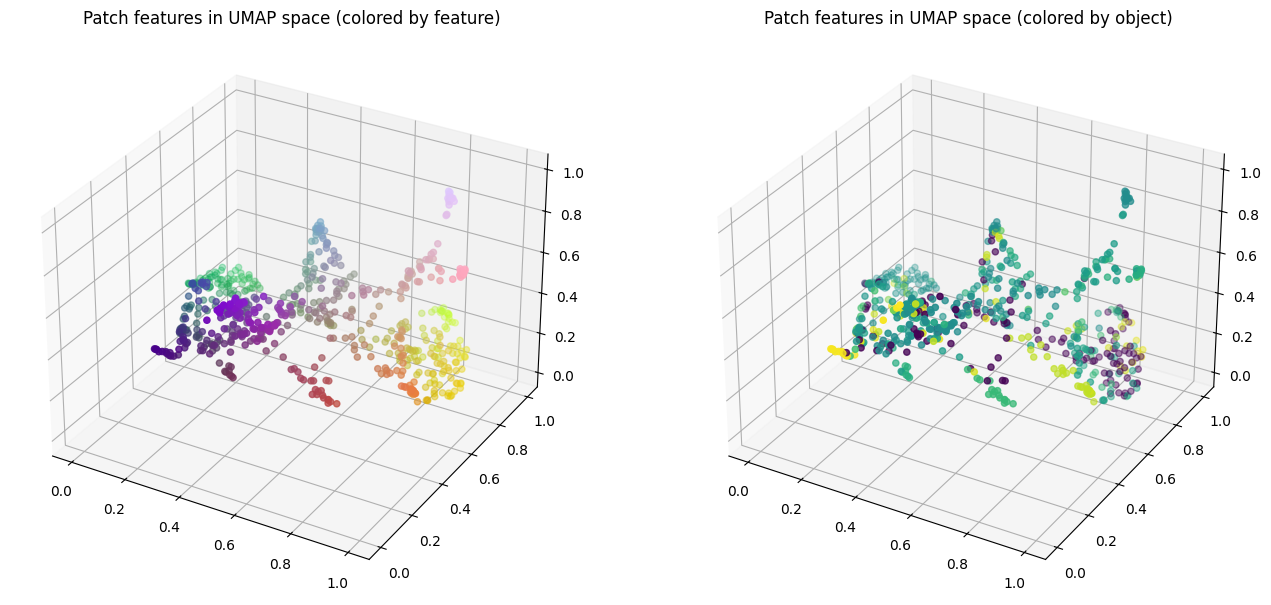

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(16, 16), subplot_kw=dict(projection='3d'))
axs[0].scatter(*patch_features_umap.T, c=patch_features_umap)
axs[0].set_title("Patch features in UMAP space (colored by feature)")
axs[1].scatter(*patch_features_umap.T, c=patch_masks.flatten())
axs[1].set_title("Patch features in UMAP space (colored by object)")
plt.show()

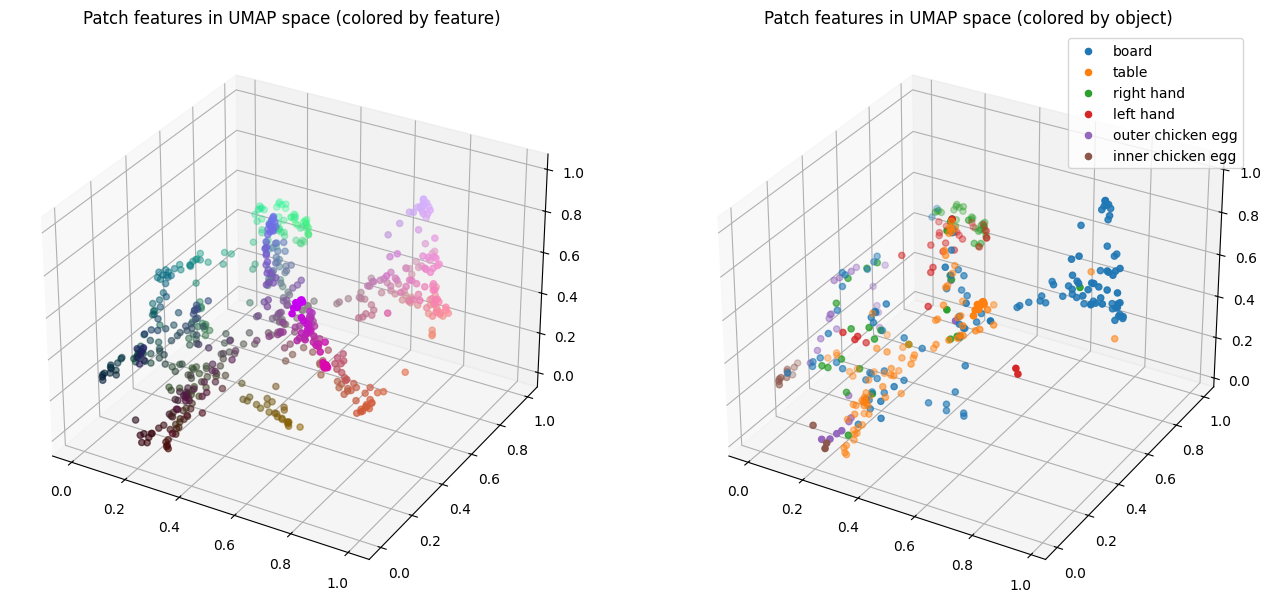

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(16, 16), subplot_kw=dict(projection='3d'))
axs[0].scatter(*patch_features_umap.T, c=patch_features_umap)
axs[0].set_title("Patch features in UMAP space (colored by feature)")
for mask_id in np.unique(patch_masks):
    if mask_id in mask_names.keys():
        axs[1].scatter(*patch_features_umap[patch_masks.flatten() == mask_id].T, label=mask_names[mask_id])
axs[1].set_title("Patch features in UMAP space (colored by object)")
axs[1].legend()
plt.show()

In [42]:
queries = ["hand", "egg", "board", "table"]
query_token_ids = processor.tokenizer(queries, return_tensors="pt")["input_ids"] #type:ignore

In [43]:
query_tokens = model.get_input_embeddings()(query_token_ids.to("cuda")) # [n_queries, seq_len, feat_dim]
query_tokens = query_tokens[:, 0, :]
query_tokens_pca = pca.transform(query_tokens.cpu().detach().to(torch.float32).numpy())

In [46]:
query_patch_cosine_sim = torch.cosine_similarity(query_tokens[:, None, :], patch_features[None, :, :], dim=-1)
effective_patch_size = patch_size * spatial_merge
patches_width, patches_height = image.width // effective_patch_size, image.height // effective_patch_size
query_patch_cosine_sim_2d = query_patch_cosine_sim.reshape(-1, patches_height, patches_width)

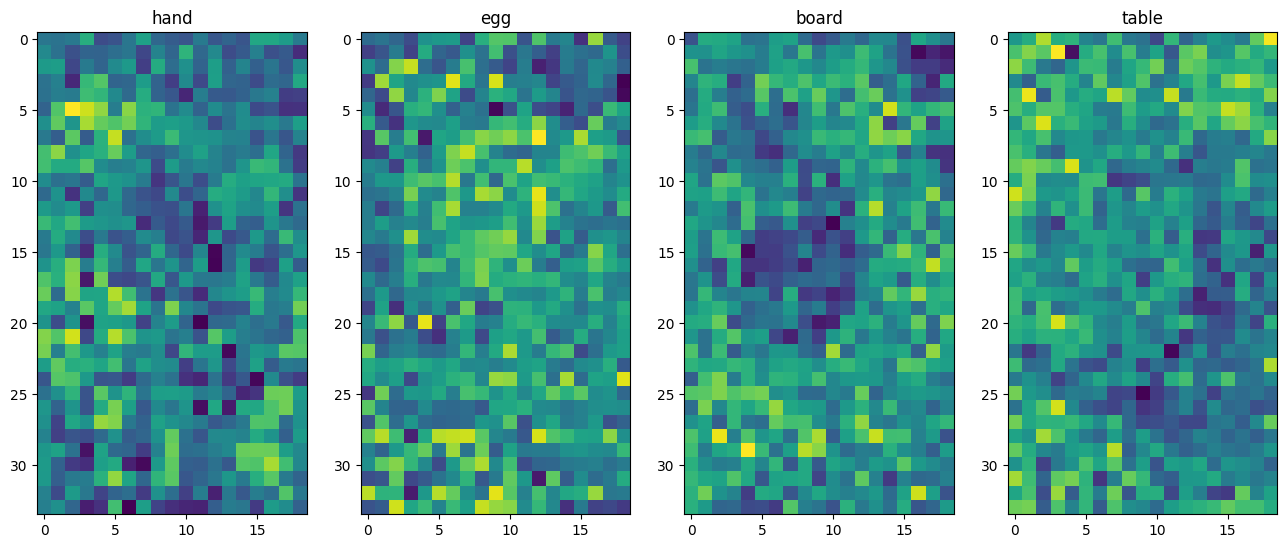

In [47]:
fig, axs = plt.subplots(1, len(queries), figsize=(16, 16))
for i, (query, activations) in enumerate(zip(queries, query_patch_cosine_sim_2d.cpu().detach().to(torch.float32).numpy())):
    axs[i].imshow(activations)
    axs[i].set_title(query)
plt.show()

In [28]:
query_tokens

tensor([[-0.0077,  0.0064, -0.0142,  ...,  0.0148, -0.0199,  0.0058],
        [ 0.0074, -0.0029, -0.0247,  ...,  0.0023,  0.0256,  0.0104],
        [-0.0125, -0.0247,  0.0410,  ...,  0.0071, -0.0025,  0.0029],
        [-0.0050,  0.0011, -0.0066,  ..., -0.0071, -0.0017, -0.0361]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SliceBackward0>)

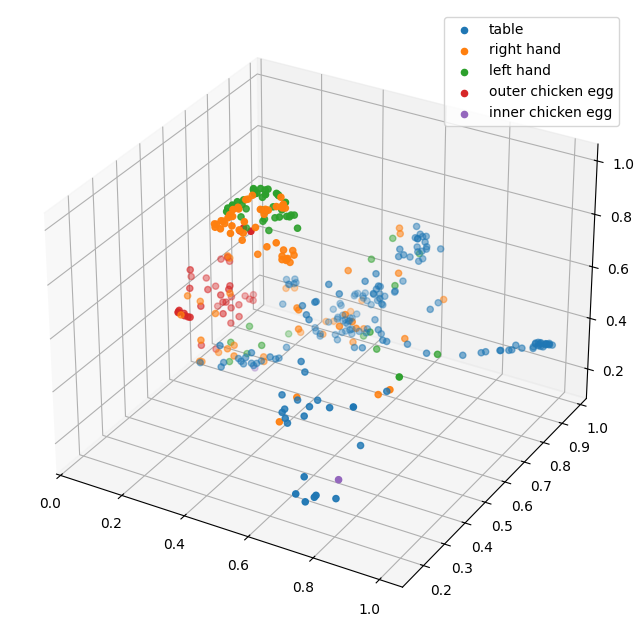

In [38]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
for mask_id in np.unique(patch_masks):
    if mask_id in mask_names.keys():
        ax.scatter(*patch_features_umap[patch_masks.flatten() == mask_id].T, label=mask_names[mask_id])
plt.legend()
plt.show()

In [30]:
torch.cdist(query_tokens, patch_features)

tensor([[101.5000,  79.0000,  28.7500,  ...,  73.0000,  42.7500,  23.3750],
        [101.5000,  79.0000,  28.7500,  ...,  73.0000,  42.7500,  23.3750],
        [101.5000,  79.0000,  28.7500,  ...,  73.0000,  42.7500,  23.3750],
        [101.5000,  79.0000,  28.7500,  ...,  73.0000,  42.7500,  23.3750]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<ViewBackward0>)

## Asking the Qwen transformer questions about the image

In [ ]:
processor(text="What does this image show?")

{'input_ids': [[3838, 1558, 419, 1943, 1473, 30]], 'attention_mask': [[1, 1, 1, 1, 1, 1]]}

In [4]:
messages = [{"role": "user", "content":
            [{"type": "image","image": None},
             {"type": "text", "text": "Describe this image."},]
}]
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
inputs = processor(
    text=[text],
    images=[cropped_image],
    padding=True,
    return_tensors="pt",
).to(model.device)

generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

Exception: Here

In [4]:
def test():
    messages = [{"role": "user", "content":
                [{"type": "image","image": None},
                {"type": "text", "text": "Describe this image."},]
    }]
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text],
        images=[cropped_image],
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    print(output_text)

In [14]:
from transformers import GenerationMixin

In [ ]:
GenerationMixin.generate

In [ ]:
model.forward

In [5]:
test()

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 23.46 GiB of which 2.88 MiB is free. Including non-PyTorch memory, this process has 23.46 GiB memory in use. Of the allocated memory 22.40 GiB is allocated by PyTorch, and 884.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [34]:
qwen_encode_image(cropped_image)

tensor([[ 1.5625,  1.9297, -1.8750,  ...,  1.6484, -3.6250,  0.1709],
        [-1.5859,  1.0000, -0.2949,  ...,  0.4531, -0.7031, -0.6328],
        [-0.5820,  0.4941,  0.4336,  ..., -0.9414,  0.1118, -0.6172],
        ...,
        [-0.6016, -0.7656,  0.3223,  ..., -2.2031, -0.1865, -0.5352],
        [ 0.0562,  0.2695,  1.3984,  ..., -1.8984, -0.3379, -0.2100],
        [-0.3789,  0.2578,  1.0703,  ..., -0.1064, -0.5508,  0.0654]],
       device='cuda:0', dtype=torch.bfloat16)

In [31]:
inputs

{'input_ids': tensor([[151644,   8948,    198,  ..., 151644,  77091,    198]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[-1.7339, -1.7193, -1.7047,  ..., -1.4376, -1.4376, -1.4518],
        [-1.7485, -1.7339, -1.7339,  ..., -1.4518, -1.4518, -1.4660],
        [-1.7485, -1.7485, -1.7485,  ..., -1.4802, -1.4802, -1.4802],
        ...,
        [ 1.5070,  1.4778,  1.4924,  ...,  1.7620,  1.7904,  1.8331],
        [ 1.2442,  1.3464,  1.4632,  ...,  1.5913,  1.6909,  1.8899],
        [ 1.4048,  1.4340,  1.4778,  ...,  2.0606,  2.0179,  2.0037]],
       device='cuda:0'), 'image_grid_thw': tensor([[ 1, 64, 64]], device='cuda:0')}

In [ ]:
print(output_text[0], )

The image shows a person's hands holding an orange plastic egg-shaped container with a lid that has a small opening. Inside the container, there is a yellow ball that resembles a chick. The container appears to be designed for holding and protecting the ball, which looks like it could be a toy or a decorative item. The container is placed on a wooden cutting board, and there is another white egg-shaped object next to it. The background includes a dark surface and a white cloth.


In [ ]:
# This function takes in an RGB image  and a prompt
def ask_qwen_about_image(image: Image.Image, prompt: str):
    messages = [{"role": "user", "content":
            [{"type": "image","image": None},
             {"type": "text", "text": prompt},]
    }]
    text = processor.apply_chat_template( #type:ignore
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(model.device)
    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

In [5]:
ask_qwen_about_image(image, "Describe this image.")

ducks


"The image shows a person's hands holding an orange egg-shaped container with a lid that has a face design on it, including eyes and a beak. Inside the container is a yellow ball that also has a face design, resembling a chick. The container appears to be designed for holding and presenting the ball in a playful manner. The scene is set on a wooden cutting board, which is placed on a dark surface. There is another white ball with a similar face design visible in the background."

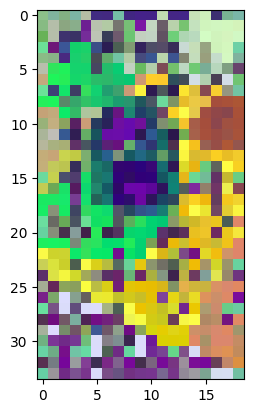

In [12]:
normal_patch_features = qwen_encode_image(image)
normal_umap = um.UMAP(n_components=3)
normal_patch_features_umap = normal_umap.fit_transform(normal_patch_features.cpu().detach().to(torch.float32).numpy())
normal_umap_scaler = MinMaxScaler((1e-4, 1-1e-4)) #type:ignore
normal_patch_features_umap = normal_umap_scaler.fit_transform(normal_patch_features_umap) #type:ignore
normal_patch_features_umap_2d = normal_patch_features_umap.reshape(34, 19, 3)
plt.imshow(normal_patch_features_umap_2d)
plt.show()

In [30]:
# This function takes in the **patch features** of an image and a prompt
def ask_qwen_about_image_features(image_features: torch.Tensor, prompt: str):
    messages = [{"role": "user", "content":
            [{"type": "image","image": None},
             {"type": "text", "text": prompt},]
    }]
    text = processor.apply_chat_template( #type:ignore
        messages, tokenize=False, add_generation_prompt=True
    )
    def closest_factor_pair(n) -> tuple[int, int]:
        root = int(math.isqrt(n))  # isqrt avoids floating-point issues
        for a in range(root, 0, -1):
            if n % a == 0:
                return a, n // a
        raise Exception("the given feature patches don't correspond to a nice rectangular size in pixels")
    effective_patch_size = patch_size * spatial_merge
    pw_dummy, ph_dummy = closest_factor_pair(image_features.shape[0])
    inputs = processor(
        text=[text],
        images=[Image.new("RGB", (effective_patch_size * pw_dummy, effective_patch_size * ph_dummy), color="red")],
        padding=True,
        return_tensors="pt",
    ).to(model.device)
    generated_ids = model.generate(**inputs, max_new_tokens=128, custom_patch_features=image_features)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

In [31]:
ask_qwen_about_image_features(patch_features, "Describe this image.")

"The image shows a person's hands holding an orange egg-shaped container with a lid that has a face design on it, including eyes and a beak. Inside the container is a yellow ball that also has a face design, resembling a chick. The container appears to be designed for holding and presenting the ball in a playful manner. The scene is set on a wooden cutting board, which is placed on a dark surface. There is another white ball with a similar face design visible in the background."

In [ ]:
def crop_patch_features(patch_feat: torch.Tensor, cw, ch, cx1, cx2, cy1, cy2):
    return patch_feat.reshape(ch, cw, -1)[cy1:cy2+1, cx1:cx2+1].flatten(end_dim=1)

In [50]:
cx1, cx2 = 5, 12
cy1, cy2 = 7, 18
cropped_patch_features = crop_patch_features(patch_features, 19, 34, cx1, cx2, cy1, cy2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0067700446..1.0392274].


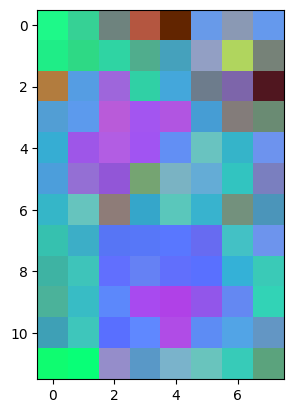

In [53]:
cropped_patch_features_umap = umap.transform(cropped_patch_features.cpu().to(torch.float32))
cropped_patch_features_umap = umap_scaler.transform(cropped_patch_features_umap).reshape(cy2-cy1+1, cx2-cx1+1, -1)
plt.imshow(cropped_patch_features_umap)
plt.show()

In [54]:
ask_qwen_about_image_features(cropped_patch_features, prompt="Describe this image.")

"The image shows a red, egg-shaped container with a lid that is open. Inside the container, there is a yellow, spherical object that resembles an egg. The yellow object has a face drawn on it, featuring two small eyes and a mouth, giving it a playful appearance. The container appears to be designed for holding or storing the yellow object, possibly as part of a toy or decorative item. The background includes a wooden surface and a person's hand holding the lid of the container."

## Trying if resizing has detremental effects

Not really. Doesn't matter anyway because the model can take nonsquare images as well.